# <B>[실습] 네이버 쇼핑 리뷰 긍부정 분류

In [23]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from konlpy.tag import Okt

from tqdm import tqdm
from nltk.corpus import stopwords

from collections import Counter
from konlpy.tag import Mecab
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# <b>Data Load

In [3]:
#urllib.request.urlretrieve("https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt", filename="lec09_ratings_total.txt")

In [6]:
df = pd.read_table("./dataset/lec09_ratings_total.txt" , names=['ratings', 'reviews'])
df.head(2)

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고


# <b>전처리 & 가공

## 결측제거

In [7]:
print(df.shape)
df = df.dropna(subset="reviews")
print(df.shape)

(200000, 2)
(200000, 2)


## 중복제거

In [8]:
print(df.shape)
df  = df.drop_duplicates(subset="reviews")
print(df.shape)

(200000, 2)
(199908, 2)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199908 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ratings  199908 non-null  int64 
 1   reviews  199908 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.6+ MB


## 한글만

In [10]:
df['reviews'] = df['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
df.head(3)

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...


## 토큰화, 불용어 처리

In [14]:
stop_words_list = stopwords.words('my_korean')    #----C:\Users\user\..\stopwords\my_korean.txt
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :',stop_words_list[:10])

불용어 개수 : 595
불용어 10개 출력 : ['가', '가까스로', '가령', '각', '각각', '각자', '각종', '갖고말하자면', '같다', '같이']


In [24]:
#mecab = Mecab(dicpath=r"C:/mecab/mecab-ko-dic") 
okt = Okt()

tokenized_data = []
for sentence in tqdm(df['reviews']):
    #tokenized_sentence = mecab.morphs(sentence)               # 형태소 토큰화
    tokenized_sentence = okt.morphs(sentence, stem=True)
    
    #불용어단어, 1글자 버리기
    stopwords_removed_sentence = [word for word in tokenized_sentence if word not in stop_words_list and len(word)>1] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 199908/199908 [12:35<00:00, 264.76it/s]


In [25]:
print( len(tokenized_data) , len(df) )
tokenized_data[:2]

# 어릴때보고 지금다시봐도 재밌어요ㅋㅋ
# [['어리다', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ'], .... ]

199908 199908


[['배공', '빠르다'], ['택배', '엉망', '이네', '없이', '놔두다']]

In [34]:
temp_list = []
for data in tokenized_data:
    temp_list.append( " ".join(data))
temp_list[:2]    

['배공 빠르다', '택배 엉망 이네 없이 놔두다']

In [35]:
df['reviews2'] = temp_list
df.head(2)

,ratings,reviews,reviews2
0,5,배공빠르고 굿,배공 빠르다
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다


In [36]:
df.to_csv("./dataset/lec09_review.csv", index=False)

## 라벨 긍부정 추가

In [38]:
df['label'] = np.select([df.ratings > 3], [1], default=0)
df.head(2)

,ratings,reviews,reviews2,label
0,5,배공빠르고 굿,배공 빠르다,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다,0


## 등장빈도 1회 단어 버리기

In [49]:
tk = Tokenizer()
tk.fit_on_texts(df['reviews2'])                        #-------------------[1]문장/단어 자르기
# print(tk.word_index)                                 #-----------사전확인 : 단어인덱스
# print(tk.word_counts)                                #-----------사전확인 : 단어빈도

<pre>tk.word_index  {'하다': 1, '좋다': 2, '너무': 3, '배송': 4, '보다': 5, ....

<pre>tk.word_counts
    OrderedDict([('배공', 5),('빠르다', 11826), ('택배', 2179), ('엉망', 777), ....

In [55]:
threshold = 2
total_cnt = len(tk.word_index) # 사전크기(단어수)
total_freq = 0                 # 전체 단어 빈도수 총 합
rare_freq  = 0                 # 등장 빈도수가 threshold보다 작은  : 1번 등장한 단어의 빈도수의 총 합
rare_cnt   = 0                 # 등장 빈도수가 threshold보다 작은  : 1번 등장한 단어의 개수를 카운트


# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tk.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 40161
등장 빈도가 1번 이하인 희귀 단어의 수: 20452
단어 집합에서 희귀 단어의 비율: 50.92502676726177
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.0884988062278396


In [62]:
vocab_sorted = sorted(tk.word_counts.items(),  key = lambda x:x[1], reverse = True)
vocab = vocab_sorted[:19709]
len(vocab_sorted[:19709])
#print(vocab_sorted[:19709])

19709

In [71]:
tokenizer = Tokenizer(len(vocab), oov_token = 'OOV') 
tokenizer.fit_on_texts(df['reviews2'])
df['reviews3'] = tokenizer.texts_to_sequences(df['reviews2'])
df.head(3)

,ratings,reviews,reviews2,label,reviews3
0,5,배공빠르고 굿,배공 빠르다,1,"[10049, 21]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배 엉망 이네 없이 놔두다,0,"[137, 359, 103, 111, 1107]"
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...,아주 좋다 바지 정말 좋다 구매 하다 가격 대박 이다 바느질 성하다 편하다 가성 최...,1,"[60, 3, 337, 49, 3, 11, 2, 22, 634, 13, 755, 8..."


In [73]:
# for n in df.loc[0,'reviews3']:
#     print(n)

# <b>EDA

## 타켓 불균형 체크

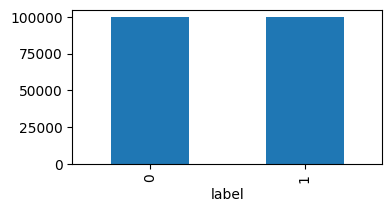

In [74]:
plt.figure(figsize=(4,2))
df['label'].value_counts().plot(kind = 'bar')
plt.show()

## 단어 길이 체크

긍정 리뷰의 평균 길이 : 26.769131491801147
부정 리뷰의 평균 길이 : 34.090550747836524
리뷰의 평균 길이 : 30.42987774376213


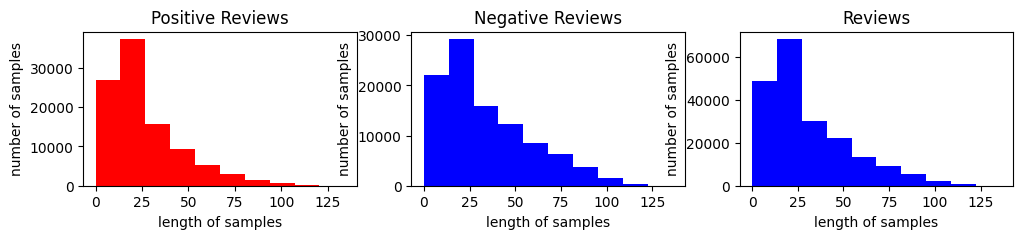

In [75]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,2))
text_len = df[df['label']==1]['reviews2'].map(lambda x: len(x))
ax1.hist(text_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('긍정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df[df['label']==0]['reviews2'].map(lambda x: len(x))
ax2.hist(text_len, color='blue')
ax2.set_title('Negative Reviews')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df['reviews2'].map(lambda x: len(x))
ax3.hist(text_len, color='blue')
ax3.set_title('Reviews')
ax3.set_xlabel('length of samples')
ax3.set_ylabel('number of samples')
print('리뷰의 평균 길이 :', np.mean(text_len))
plt.show()

## 워드 클라우드

In [ ]:
#! pip install wordcloud

In [79]:
negative_words = np.hstack(df[df.label == 0]['reviews2'].values)
positive_words = np.hstack(df[df.label == 1]['reviews2'].values)

print(type(negative_words), negative_words.shape)

negative_word_count = Counter(negative_words)
print(negative_word_count.most_common(10))

print("---"*20)
positive_word_count = Counter(positive_words)
print(positive_word_count.most_common(10))

<class 'numpy.ndarray'> (99955,)
[(np.str_('그냥 그렇다'), 69), (np.str_(''), 58), (np.str_('배송 너무 느리다'), 42), (np.str_('그렇다'), 41), (np.str_('좋다'), 41), (np.str_('배송 느리다'), 37), (np.str_('별로'), 33), (np.str_('배송 너무 늦다'), 30), (np.str_('재다'), 28), (np.str_('효과 없다'), 26)]
------------------------------------------------------------
[(np.str_('좋다'), 118), (np.str_('배송 빠르다 좋다'), 50), (np.str_(''), 39), (np.str_('재다'), 37), (np.str_('맛있다 먹다'), 36), (np.str_('맛있다'), 35), (np.str_('좋다 잘쓰다'), 29), (np.str_('만족하다'), 28), (np.str_('먹다'), 25), (np.str_('너무 좋다'), 25)]


In [81]:
from wordcloud import WordCloud

In [82]:
def MY_CLOUD_CHART(data):
    wc = WordCloud(font_path='C:\\Windows\\Fonts\\\x7f\x7f\x7f\x7fBOLD.TTF'
                   ,background_color="white", max_font_size=60)
    try : 
        if type(data) == str:
            cloud = wc.generate(data)
        else :
            cloud = wc.generate_from_frequencies(dict(data))

        # cloud.to_file('test.jpg')

        plt.figure(figsize=(5, 3))
        plt.axis('off')
        plt.imshow(cloud)
        plt.show()
    except:
        print("파라미터는 str 또는 dict만 지원합니다")
